[Reference](https://python.plainenglish.io/understanding-q-learning-the-original-smart-algorithm-961ac29c4cb7)

Episode: 0, Epsilon: 1.0000, Episode Rewards: 38, Average Reward: 38
Episode: 1000, Epsilon: 0.6065, Episode Rewards: 20, Average Reward: 29
Episode: 2000, Epsilon: 0.3678, Episode Rewards: 58, Average Reward: 48
Episode: 3000, Epsilon: 0.2230, Episode Rewards: 74, Average Reward: 62
Episode: 4000, Epsilon: 0.1353, Episode Rewards: 185, Average Reward: 81
Training finished.


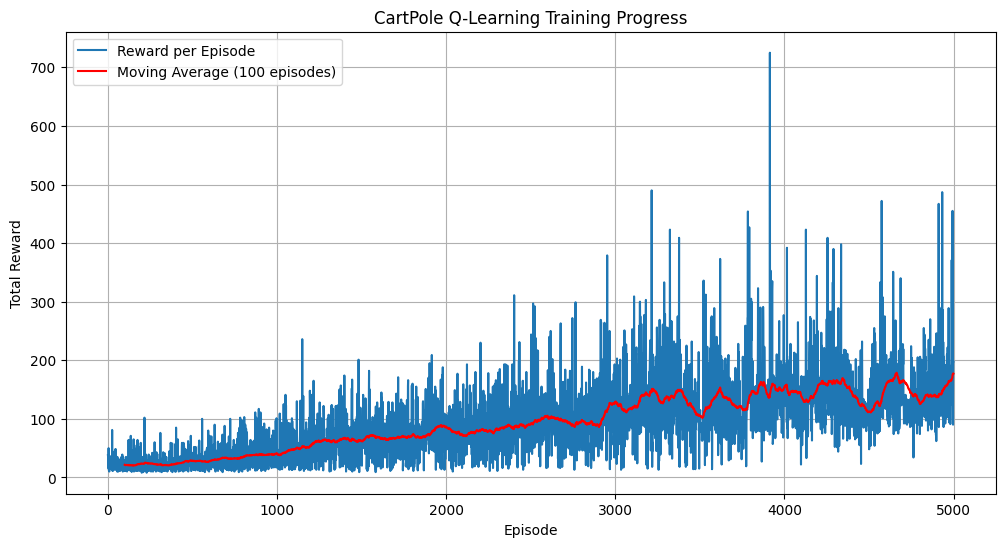


--- Watching Trained Agent ---

--- Watching Trained Agent ---

--- Watching Trained Agent ---


In [ ]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

# --- Part 1: Training the Agent (with reward tracking) ---

# 1. Create the environment
# We use 'rgb_array' for training so it's faster. We'll create a new
# environment with 'human' mode for watching it later.
env = gym.make("CartPole-v1")

# 2. Discretize the state space
pos_bins = np.linspace(-2.4, 2.4, 10)
vel_bins = np.linspace(-4, 4, 10)
angle_bins = np.linspace(-0.209, 0.209, 10)
angle_vel_bins = np.linspace(-4, 4, 10)

q_table = np.random.uniform(low=-1, high=1, size=([10, 10, 10, 10] + [env.action_space.n]))

# --- Hyperparameters ---
learning_rate = 0.1
discount = 0.95
episodes = 5000
epsilon = 1.0
epsilon_decay = 0.9995 # Slightly slower decay

# --- VISUALIZATION SETUP ---
# List to store total rewards for each episode
episode_rewards = []

# Helper function to convert a continuous state to a discrete one
def get_discrete_state(state):
    discrete_state = (np.digitize(state[0], pos_bins) - 1,
                      np.digitize(state[1], vel_bins) - 1,
                      np.digitize(state[2], angle_bins) - 1,
                      np.digitize(state[3], angle_vel_bins) - 1)
    return discrete_state

# --- Training Loop ---
for episode in range(episodes):
    state_tuple = get_discrete_state(env.reset(seed=episode)[0])
    terminated = False
    current_episode_reward = 0

    while not terminated:
        # Epsilon-greedy action selection
        if np.random.random() > epsilon:
            action = np.argmax(q_table[state_tuple])
        else:
            action = env.action_space.sample()

        new_state, reward, terminated, truncated, _ = env.step(action)
        new_state_tuple = get_discrete_state(new_state)

        # Update Q-table
        current_q = q_table[state_tuple + (action,)]
        max_future_q = np.max(q_table[new_state_tuple])

        new_q = current_q + learning_rate * (reward + discount * max_future_q - current_q)
        q_table[state_tuple + (action,)] = new_q

        state_tuple = new_state_tuple
        current_episode_reward += reward

    # --- TRACK REWARDS ---
    episode_rewards.append(current_episode_reward)

    # Print progress
    if episode % 1000 == 0:
        print(f"Episode: {episode}, Epsilon: {epsilon:.4f}, Episode Rewards: {current_episode_reward:.0f}, Average Reward: {np.average(episode_rewards):.0f}")

    # Decay epsilon
    if epsilon > 0.05:
        epsilon *= epsilon_decay

env.close()
print("Training finished.")

# --- Part 2: Plotting the Learning Curve ---

# Calculate moving average
moving_avg_rewards = np.convolve(episode_rewards, np.ones(100)/100, mode='valid')

plt.figure(figsize=(12, 6))
plt.plot(episode_rewards, label='Reward per Episode')
plt.plot(range(99, len(episode_rewards)), moving_avg_rewards, label='Moving Average (100 episodes)', color='red')
plt.title('CartPole Q-Learning Training Progress')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.legend()
plt.grid(True)
plt.show()


# --- Part 3: Watching the Trained Agent ---

# Create a new environment with "human" render mode to watch the agent
watch_env = gym.make("CartPole-v1", render_mode='human')

for _ in range(5): # Watch 5 episodes
    state_tuple = get_discrete_state(watch_env.reset()[0])
    terminated = False
    print("\n--- Watching Trained Agent ---")

    while not terminated:
        # Always exploit the learned policy (no exploration)
        action = np.argmax(q_table[state_tuple])

        # Take the best action
        new_state, _, terminated, truncated, _ = watch_env.step(action)
        state_tuple = get_discrete_state(new_state)

        # Render the environment to the screen
        watch_env.render()

watch_env.close()